**NOTE:** If you were still not able to install or get anaconda running, please refer to the [Detailed Installation](#cell-details) Section at the bottom.

In the following examples, if a package is not installed in your environment, you should install it yourself.

In the case you are using the `conda` environment created during last class (`ac1`). Then you should always prefer to use it to install packages, since:
- Conda provides a full SAT-based dependency resolver that ensures global environment consistency across Python and non-Python libraries.
- It distributes precompiled, ABI-compatible binaries (e.g., MKL, CUDA, BLAS), reducing compilation issues and runtime conflicts.
- It manages system-level dependencies alongside Python packages, making complex scientific and ML stacks substantially more stable and reproducible.

It should be noted that some packages might not be available in `conda`, and those will inevitably have to be installed using `pip`.

So, prefer:

```bash
conda install <package_name>
```

And only use:

```bash
pip install <package_name>
```

When the former is not avaialble.

If for some reason you are not using the `conda` environment. Then you will have to install those using `pip`.

Your task is to use the Hotel Reservation dataset to explore the outcomes of the CART algorithm for predicting whether a reservation will be canceled.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz

In [50]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, accuracy_score, roc_auc_score

1. Read the Hotel Reservation data set  into a data frame.
2. For the set of predictors, select the columns 'required_car_parking_space', 'lead_time', 'repeated_guest', 'avg_price_per_room' and those whose name starts with 'no_of_'. For the target variable,  map column 'booking_status' values to 1 for 'Canceled' and 0 for 'Not Canceled'.

In [51]:
# 1.
file_path = "HotelReservations.csv"
df = pd.read_csv(file_path)

In [52]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

3. Define a simple decision tree classifier with max_depth = 5. Check which split criterion is set by default.

4. Define a train/test split of the data set  with a test size equal to 30%. Hint: use the function 'train_test_split()'. Fit the decision tree classifier to the training data and evaluate its accuracy on the test data. Hint: use the functions ‘fit()’, ‘predict()’ and  ‘accuracy_score()’.

In [53]:
# 2.
no_of = [col for col in df.columns if 'no_of' in col]
X = df[['required_car_parking_space', 'lead_time', 'repeated_guest', 'avg_price_per_room'] + no_of]
Y = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

In [54]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.3,
    random_state = 42, 
    shuffle = True        
)

In [55]:
tree = DecisionTreeClassifier(max_depth = 5)
tree.fit(X_train, Y_train)
y_pred = tree.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)

In [56]:
# Visualize the decision tree using graphviz. If your fit was done correctly, it should work. 
def myplot_tree(tree,X,y,class_names=['not canceled','canceled']):
    # Export decision tree to DOT format
    dot_data = export_graphviz(tree, out_file = None,
                           feature_names = X.columns,
                           class_names = class_names,
                           filled = True, rounded = True,
                           special_characters = True)

    # Plot decision tree
    graph = graphviz.Source(dot_data)
    graph.render("decision_tree")  # save to file
    graph.view()  # open in viewer

In [57]:
myplot_tree(tree,X_train, Y_train)

5. Define a function that displays the confusion matrix and the accuracy, given a fitted model, the predictors and the target of the test set, Hint: use the functions 'confusion_matrix()' and 'ConfusionMatrixDisplay()'.


Accuracy =  0.8092


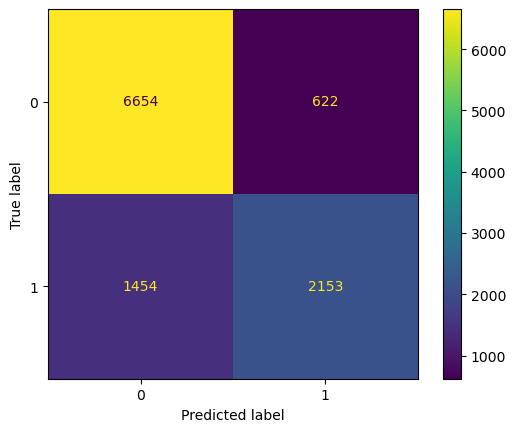

In [58]:
def plot_cm (model_fit, X_test, Y_test):
    print("Accuracy = ", round(accuracy, 4))
    cm = confusion_matrix(y_true = Y_test, y_pred =y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix = cm)
    disp.plot()

plot_cm(tree, X_test, Y_test)

6. Define a function that plots the ROC curve and respective AUC, given a fitted model, the predictors and the target of the test set. Hint: use the functions ‘predict_proba()’, ‘roc_curve()’ and ‘roc_auc_score()’.


In [59]:
def plot_roc_curve(model_fit, X_test, Y_test):
    y_pred_prob = model_fit.predict_proba(X_test)[:, 1] # probability for the positive class
    fpr, tpr, _ = roc_curve(y_true = Y_test, y_score= y_pred_prob)
    auc = roc_auc_score(Y_test, y_pred_prob)

    # Create ROC curve
    plt.plot(fpr,tpr, label="AUC="+str(round(auc,3)))
    plt.plot(np.linspace(0,1,5),np.linspace(0,1,5),linestyle='--',linewidth=0.5,color="grey")
    plt.show()

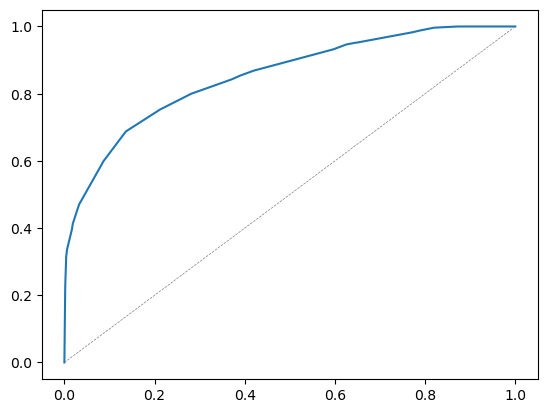

In [60]:
plot_roc_curve(tree, X_test, Y_test)

7. Define a function ‘holdout_estimation()’ that receives an unfitted model, the set of predictors, the target, and the size of the test partition and returns the accuracy estimate.


In [61]:
def holdout_estimation(model, X, Y, size):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size= size, random_state=42
    )
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    return accuracy

8. Define a function ‘cv_estimation()’ that receives an unfitted model, the set of predictors, the target, and the number of k for the k-fold cv and returns the accuracy estimate (mean and standard deviation). Hint: If you don’t want to obtain all the partitions for training/testing, you can use the function ‘cross_val_score()’.


In [62]:
def cv_estimation(model, X, Y, k):
    scores = cross_val_score(model, X, Y, cv = k, scoring = 'accuracy')
    mean = scores.mean()
    std = scores.std()
    return mean, std

9. Train decision trees with different values for the hyperparameters max_depth, min_samples_split, min_samples_leaf, and min_impurity_decrease. Analyze how that impacts the fitted model's performance by holdout and cross-validation.


In [63]:
new_tree = DecisionTreeClassifier(max_depth=20)
holdout_estimation(new_tree, X , Y, 0.20)
cv_estimation(new_tree, X_train ,Y_train, 10)

(np.float64(0.8405405438932186), np.float64(0.007845721238922604))

10. For a decision tree with a max_depth of 20, consider that partitions of increasing size (e.g. from 10% to 100%, with steps of 10%) are given for training the model with the remaining partition for testing. Check how the performance on the train and the test sets evolves. Hint: use the function learning_curve() that determines cross-validated training and test scores for different training set sizes.

In [64]:
def plot_learning_curves(model, X, Y,title=''):
    tr_size = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    train_sizes, train_scores, test_scores = learning_curve(model, X, Y, scoring='accuracy', train_sizes=tr_size)

    for tr_size, cv_tr_score, cv_ts_score in zip(train_sizes,train_scores,test_scores):
        print("Train size:",tr_size,"Train score:",round(cv_tr_score.mean(),3),"Test score:",round(cv_ts_score.mean(),3))

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot training scores
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training accuracy', linewidth=2)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    
    # Plot cross-validation scores
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation accuracy', linewidth=2)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                     alpha=0.1, color='red')
    
    # Customize the plot
    plt.xlabel('Training Examples', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Learning Curves {title}', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Set y-axis limits to better visualize the range
    plt.ylim([0.5, 1.0])  # Adjust based on your expected accuracy range
    
    # Add a horizontal line at 1.0 for perfect accuracy reference
    plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return train_sizes, train_mean, test_mean

Train size: 2902 Train score: 0.904 Test score: 0.804
Train size: 5804 Train score: 0.883 Test score: 0.817
Train size: 8706 Train score: 0.873 Test score: 0.824
Train size: 11608 Train score: 0.867 Test score: 0.829
Train size: 14510 Train score: 0.865 Test score: 0.836
Train size: 17412 Train score: 0.864 Test score: 0.835
Train size: 20314 Train score: 0.862 Test score: 0.84
Train size: 23216 Train score: 0.862 Test score: 0.841
Train size: 26118 Train score: 0.859 Test score: 0.84
Train size: 29020 Train score: 0.857 Test score: 0.841


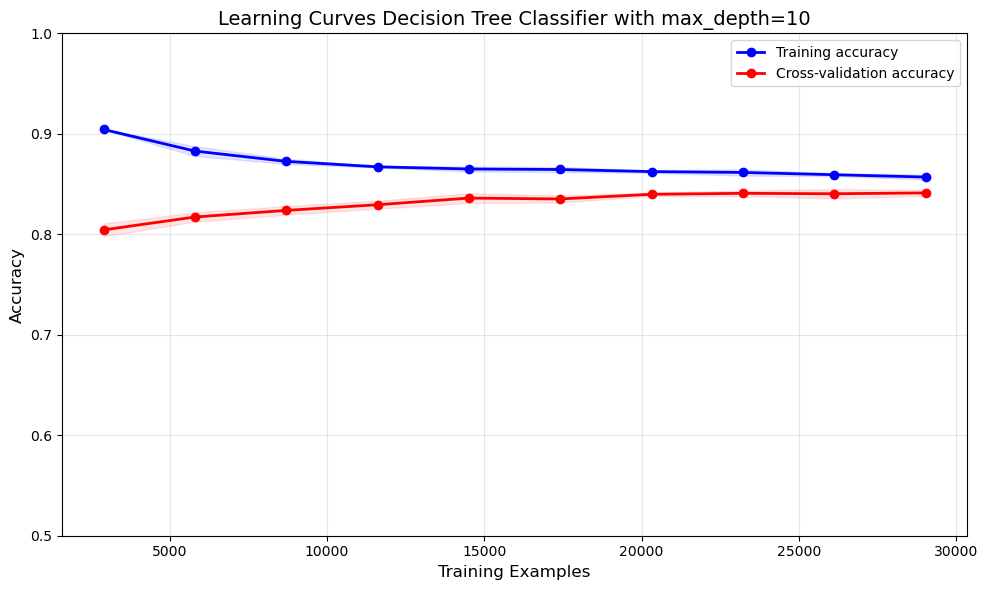

Train size: 2902 Train score: 0.988 Test score: 0.789
Train size: 5804 Train score: 0.988 Test score: 0.802
Train size: 8706 Train score: 0.981 Test score: 0.812
Train size: 11608 Train score: 0.972 Test score: 0.826
Train size: 14510 Train score: 0.971 Test score: 0.828
Train size: 17412 Train score: 0.968 Test score: 0.835
Train size: 20314 Train score: 0.967 Test score: 0.841
Train size: 23216 Train score: 0.968 Test score: 0.841
Train size: 26118 Train score: 0.965 Test score: 0.845
Train size: 29020 Train score: 0.962 Test score: 0.85


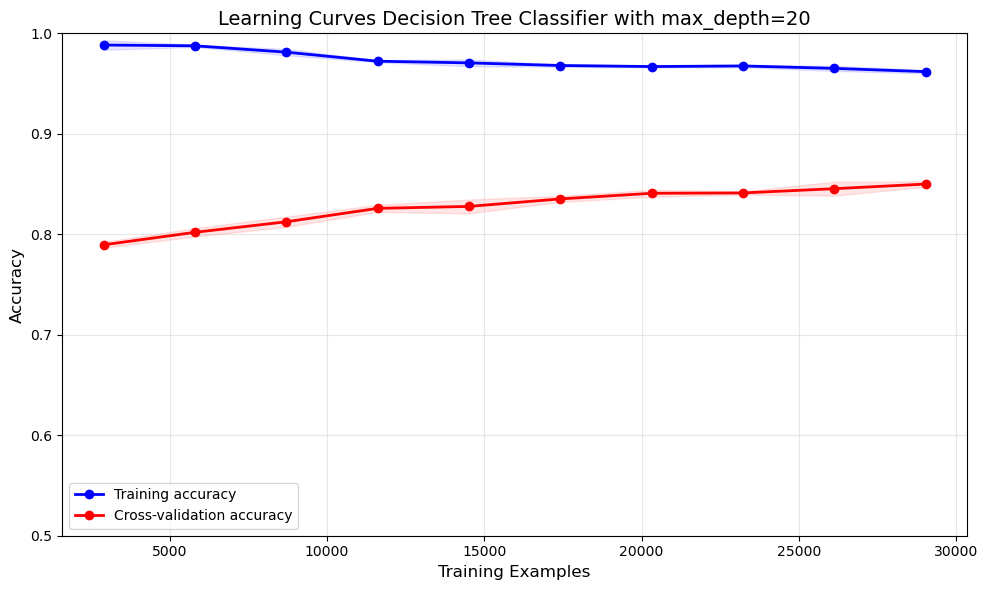

In [65]:
for max_depth in [10,20]:
    tree_d = DecisionTreeClassifier(max_depth=max_depth)
    plot_learning_curves(tree_d, X, Y, title = 'Decision Tree Classifier with max_depth='+str(max_depth))

<a name="cell-details"></a>
___
## Detailed Instalation Details (and how to fix previous installations)

<a id="setup-env"></a>
### Setup an environment for AC 1 course

---

1. Installing Miniconda
2. Creating the `ac1` environment
3. Adding Conda to PATH (if already installed)
4. Using the environment in VS Code
5. Using the environment in PyCharm

---

# 1. Install Miniconda

## Windows

1. Download Miniconda (64-bit) from:
   [https://docs.conda.io/en/latest/miniconda.html](https://docs.conda.io/en/latest/miniconda.html)

2. Run the installer:

   * Select **“Just for Me”**
   * Check **“Add Miniconda to my PATH”** (recommended)
   * Allow it to initialize Conda

3. Open a new Command Prompt or PowerShell and verify:

```bash
conda --version
```

If a version number appears, installation succeeded.

---

## macOS

1. Download the `.pkg` installer from the Miniconda website.
2. Run the installer.
3. Restart Terminal.
4. Verify:

```bash
conda --version
```

If not found, run:

```bash
source ~/.bashrc
```

or (if using zsh):

```bash
source ~/.zshrc
```

---

## Linux

Download:

```bash
wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
```

Install:

```bash
bash Miniconda3-latest-Linux-x86_64.sh
```

Restart terminal and verify:

```bash
conda --version
```

---

# 2. If Conda Is Already Installed But Not in PATH

This section explains how to manually add Conda to your system PATH so that the `conda` command works in any terminal.

---

# Windows

## Step 1 - Locate Your Miniconda Installation Folder

The default installation path is usually:

```
C:\Users\<your_username>\Miniconda3
```

If you are unsure:

1. Open File Explorer.
2. Navigate to:
   ```
   C:\Users\<your_username>\
   ```
3. Look for a folder named:
   - `Miniconda3`
   - `Anaconda3`
   - or similar

If you installed it system-wide, it may be located in:

```
C:\ProgramData\Miniconda3
```

---

## Step 2 - Open Environment Variables Settings

1. Press:
   ```
   Windows Key + S
   ```
2. Search for:
   ```
   Environment Variables
   ```
3. Click:
   ```
   Edit the system environment variables
   ```
4. In the System Properties window, click:
   ```
   Environment Variables
   ```

---

## Step 3 - Edit the PATH Variable

Under **User variables** (recommended) or **System variables**:

1. Select:
   ```
   Path
   ```
2. Click:
   ```
   Edit
   ```
3. Click:
   ```
   New
   ```
4. Add the following entries (adjust username):

```
C:\Users\<your_username>\Miniconda3
C:\Users\<your_username>\Miniconda3\Scripts
C:\Users\<your_username>\Miniconda3\Library\bin
```

Add each one separately.

5. Click **OK** to confirm.
6. Close all open windows.

---

## Step 4 - Restart Terminal

Important: Close all Command Prompt, PowerShell, and VS Code terminals.

Open a new Command Prompt and verify:

```bash
conda --version
```

If correctly configured, you should see something like:

```
conda 23.x.x
```

---

## Step 5 - If It Still Does Not Work

Try initializing Conda manually:

```bash
C:\Users\<your_username>\Miniconda3\Scripts\conda.exe init
```

Then restart the terminal again.

You may also try:

```bash
conda init powershell
```

or

```bash
conda init cmd.exe
```

Restart the terminal afterward.

---

# macOS / Linux - Detailed Instructions

## Step 1 - Locate Miniconda Installation

Default location:

```
~/miniconda3
```

Check if it exists:

```bash
ls ~/miniconda3
```

If installed elsewhere, locate it with:

```bash
which conda
```

---

## Step 2 - Add Conda to PATH

Open your shell configuration file:

### If using bash:
```bash
nano ~/.bashrc
```

### If using zsh (default on modern macOS):
```bash
nano ~/.zshrc
```

Add this line at the bottom:

```bash
export PATH="$HOME/miniconda3/bin:$PATH"
```

Save and exit.

---

## Step 3 - Reload Configuration

```bash
source ~/.bashrc
```

or

```bash
source ~/.zshrc
```

---

## Step 4 - Verify

```bash
conda --version
```

If it still fails, initialize Conda:

```bash
~/miniconda3/bin/conda init
```

Then restart the terminal.

---

# Final Verification

After PATH is properly configured, this should work from any terminal:

```bash
conda info
```

If it prints environment details, Conda is correctly installed and accessible.

---

# 3. Create the AC1 Environment

Create environment:

```bash
conda create -n ac1 python=3.11 -y
```

Activate:

```bash
conda activate ac1
```

Install core packages:

```bash
conda install -c conda-forge numpy pandas scipy scikit-learn matplotlib seaborn plotly jupyterlab ipywidgets tqdm
```

Verify:

```bash
python -c "import numpy, pandas, sklearn; print('AC1 ready')"
```

If `(ac1)` appears in your terminal prompt, the environment is active.

(**NOTE:** In most cases, you will be provided with an environment file similar to the one given, and will only need to run `conda env create -f <environment_name>.yml`. This makes it easy to replicate results from papers or experiments using the correct versions of Python and packages.)


---

# 4. Using AC1 in the Terminal

Activate:

```bash
conda activate ac1
```

Deactivate:

```bash
conda deactivate
```

List environments:

```bash
conda env list
```

Remove environment:

```bash
conda remove -n ac1 --all
```

---

# 5. Using AC1 in Visual Studio Code

## Step 1 - Install VS Code

Download from:
[https://code.visualstudio.com/](https://code.visualstudio.com/)

Install the **Python extension** (Microsoft official extension).

---

## Step 2 - Select the Conda Environment

1. Open VS Code.
2. Open your project folder.
3. Press:

```
Ctrl + Shift + P
```

4. Type:

```
Python: Select Interpreter
```

5. Select the interpreter that contains:

```
ac1 (Python 3.11)
```

If it does not appear:

* Restart VS Code
* Ensure `conda activate ac1` works in a terminal

---

## Step 3 - Use Integrated Terminal

Inside VS Code:

```
Terminal → New Terminal
```

Then activate:

```bash
conda activate ac1
```

---

# 6. Using AC1 in PyCharm

## Step 1 - Install PyCharm

Download from:
[https://www.jetbrains.com/pycharm/](https://www.jetbrains.com/pycharm/)

Community edition is sufficient.

---

## Step 2 - Configure Conda Environment in PyCharm

1. Open PyCharm.
2. Create or open a project.
3. Go to:

```
File → Settings → Project → Python Interpreter
```

4. Click the gear icon → **Add Interpreter**
5. Select:

```
Conda Environment
```

6. Choose:

```
Existing Environment
```

7. Browse and select:

### Windows:

```
C:\Users\<user>\Miniconda3\envs\ac1\python.exe
```

### macOS/Linux:

```
~/miniconda3/envs/ac1/bin/python
```

8. Click OK.

PyCharm will now use the `ac1` environment.

---

## Alternative: Create Conda Environment Directly from PyCharm

Inside interpreter settings:

* Choose **New Conda Environment**
* Name it `ac1`
* Python 3.11
* Click Create

---

# 7. Verify in PyCharm

Open Python console in PyCharm and run:

```python
import sys
print(sys.executable)
```

It should point to:

```
.../envs/ac1/...
```
